# Error Handling Eval EDA
**항목 15: 오류 대응** (`practice` 카테고리, `keyword` 전략)

## 목적
실습 구간(`llm_label == '실습'`)에서 강사의 오류 대응 발화를 탐지·검증하고
LLM 채점 근거(regex 패턴, few-shot 예시, BoW 키워드)를 도출한다.

## 파이프라인
```
anchored_labeled.json (실습 청크)
    → Regex 후보 탐지
    → LLM yes/no 검증  (에러 대응 발화인가?)
    → precision 분석 + false positive 패턴 확인
    → BoW 키워드 / few-shot 예시 확정
```

In [20]:
import re
import json
import asyncio
import os
from pathlib import Path
from collections import Counter

import pandas as pd
from dotenv import load_dotenv

load_dotenv("../.env")

DATA_DIR      = Path("../data")
LABELED_PATH  = DATA_DIR / "anchored_labeled.json"
KSS_PATH      = DATA_DIR / "processed/lectures_kss.csv"

## 1. 데이터 로드

In [21]:
with open(LABELED_PATH, encoding="utf-8") as f:
    all_chunks = json.load(f)

df_kss = pd.read_csv(KSS_PATH)

practice_chunks = [c for c in all_chunks if c["llm_label"] == "실습"]

print(f"전체 청크 : {len(all_chunks)}개")
print(f"실습 청크 : {len(practice_chunks)}개")
print(f"KSS 문장  : {len(df_kss):,}개")
print()

# llm_label 분포
label_dist = Counter(c["llm_label"] for c in all_chunks)
for k, v in label_dist.most_common():
    print(f"  {k}: {v}개")

전체 청크 : 385개
실습 청크 : 188개
KSS 문장  : 24,238개

  실습: 188개
  개념: 83개
  예시: 72개
  기타: 42개


In [22]:
# 실습 청크 기본 통계
text_lens = [len(c["text"]) for c in practice_chunks]

print(f"text 길이 — 평균: {sum(text_lens)/len(text_lens):.0f}자 "
      f"/ 최소: {min(text_lens)} / 최대: {max(text_lens)}")
print()

# llm_label 분포 (기존 분류 결과)
llm_dist = Counter(c.get("llm_label", "없음") for c in practice_chunks)
print("기존 llm_label 분포:")
for k, v in llm_dist.most_common():
    print(f"  {k}: {v}개")

text 길이 — 평균: 1370자 / 최소: 268 / 최대: 4851

기존 llm_label 분포:
  실습: 188개


## 2. Regex 패턴 정의

오류 대응 발화 탐지 전략:
- **직접 오류 언급**: 에러·오류·워닝 키워드
- **IDE/실행 결과 언급**: 빨간 줄, 안 나와요, 안 떠요
- **교사 수정 유도**: 이렇게 하면 안 돼, 확인해, 수정해
- **학생 오류 보고 맥락**: 막혔어요, 안 되는데요

→ 위 패턴은 정상 개념 설명에서도 등장할 수 있으므로 LLM yes/no 검증 필요

In [23]:
# ── 오류 직접 언급 ────────────────────────────────────────────────────────
ERROR_DIRECT_PATTERNS = [
    r"에러가?\s*(났|나|떴|뜨|잡|있|생)",
    r"오류가?\s*(났|나|떴|뜨|잡|있|생)",
    r"에러\s*(메세지|메시지|코드|내용|보면|확인)",
    r"오류\s*(메세지|메시지|코드|내용|보면|확인)",
    r"(런타임|컴파일|문법)\s*(에러|오류)",
    r"워닝\s*(났|나|떴|뜨|잡|있)",
    r"(경고|warning)\s*(났|나|떴|뜨|있)",
    r"빨간\s*줄",
    r"빨간색\s*(표시|밑줄|선)",
    r"null\s*pointer",
    r"exception\s*(났|나|떴|잡)",
]

# ── IDE/실행 결과 기반 오류 인식 ──────────────────────────────────────────
ERROR_SYMPTOM_PATTERNS = [
    r"안\s*나와(요|서|도)?",
    r"안\s*떠(요|서|도)?",
    r"안\s*실행(돼|되)",
    r"실행\s*안\s*(돼|되)",
    r"결과가?\s*(안\s*나|안\s*뜨|틀려|이상해)",
    r"막혔(어요?|는데)",
    r"안\s*되는(데|거|건)",
    r"안\s*(돼요|됩니다|되는\s*거)",
    r"왜\s*(이러|그러|안\s*되)",
    r"(이게|이거)\s*문제",
    r"거기서\s*막히",
]

# ── 교사 수정 유도 / 오류 해결 설명 ──────────────────────────────────────
# 제거: (이렇게 바꾸면|이렇게 해야|이렇게 수정) — FP 43%
ERROR_FIX_PATTERNS = [
    r"(이렇게\s*하면|그렇게\s*하면)\s*안\s*(돼|됩니|되는)",
    r"(여기|이\s*부분|이거)\s*(수정|고쳐|바꿔)",
    r"(수정|고쳐|다시\s*봐|다시\s*확인)(해|봐|야|하면|하세요)",
    r"(왜\s*안\s*되냐|왜\s*에러|왜\s*오류)",
    r"(오류\s*잡|에러\s*잡|오류를\s*고|에러를\s*고)",
    r"다시\s*(해보|실행|확인)(해|봐|요)?",
]

ALL_PATTERNS = ERROR_DIRECT_PATTERNS + ERROR_SYMPTOM_PATTERNS + ERROR_FIX_PATTERNS

error_re = re.compile("|".join(ALL_PATTERNS), re.IGNORECASE)

print(f"패턴 수: {len(ALL_PATTERNS)}개")
print(f"  직접 언급: {len(ERROR_DIRECT_PATTERNS)}개")
print(f"  증상 기반: {len(ERROR_SYMPTOM_PATTERNS)}개")
print(f"  수정 유도: {len(ERROR_FIX_PATTERNS)}개")

패턴 수: 28개
  직접 언급: 11개
  증상 기반: 11개
  수정 유도: 6개


## 3. Regex 적용 — 실습 청크 후보 탐지

In [24]:
def find_error_hits(text: str) -> list[dict]:
    """텍스트에서 오류 대응 패턴 전체 히트 반환."""
    hits = []
    for pattern in ALL_PATTERNS:
        for m in re.finditer(pattern, text, re.IGNORECASE):
            hits.append({
                "start":   m.start(),
                "end":     m.end(),
                "matched": m.group(),
                "pattern": pattern,
                "context": text[max(0, m.start()-60): m.end()+60],
            })
    return sorted(hits, key=lambda x: x["start"])


rows = []
for chunk in practice_chunks:
    hits = find_error_hits(chunk["text"])
    rows.append({
        "file":         chunk["file"][:10],
        "anchor_dt":    chunk["anchor_dt"],
        "anchor_text":  chunk["anchor_text"],
        "llm_label":    chunk.get("llm_label", ""),
        "text":         chunk["text"],
        "text_len":     len(chunk["text"]),
        "hit_count":    len(hits),
        "has_hit":      len(hits) > 0,
        "hits":         hits,
        "first_match":  hits[0]["matched"] if hits else None,
        "first_context": hits[0]["context"] if hits else None,
    })

df = pd.DataFrame(rows)

hit_df    = df[df["has_hit"]].copy()
no_hit_df = df[~df["has_hit"]].copy()

print(f"실습 청크 전체  : {len(df)}개")
print(f"Regex 히트      : {len(hit_df)}개  ({len(hit_df)/len(df)*100:.1f}%)")
print(f"Regex 미탐지    : {len(no_hit_df)}개  ({len(no_hit_df)/len(df)*100:.1f}%)")

실습 청크 전체  : 188개
Regex 히트      : 58개  (30.9%)
Regex 미탐지    : 130개  (69.1%)


## 4. EDA — Regex 히트 분석

In [25]:
# 4-1. 파일별 히트 수
file_hit = df.groupby("file").agg(
    total=("has_hit", "count"),
    hits=("has_hit", "sum"),
).assign(ratio=lambda x: (x["hits"] / x["total"] * 100).round(1))

print("[파일별 Regex 히트율]")
print(file_hit.to_string())

[파일별 Regex 히트율]
            total  hits  ratio
file                          
2026-02-02     14     2   14.3
2026-02-03     10     5   50.0
2026-02-04     18     8   44.4
2026-02-05     10     1   10.0
2026-02-06     12     2   16.7
2026-02-09     15     6   40.0
2026-02-10     13     1    7.7
2026-02-11     12     7   58.3
2026-02-12      8     0    0.0
2026-02-13     13     4   30.8
2026-02-23     22     4   18.2
2026-02-24     18    12   66.7
2026-02-25      9     2   22.2
2026-02-26      5     1   20.0
2026-02-27      9     3   33.3


In [26]:
# 4-2. 패턴별 히트 빈도
all_hits_flat = []
for row in rows:
    for h in row["hits"]:
        all_hits_flat.append({
            "pattern": h["pattern"],
            "matched": h["matched"],
        })

hit_flat_df = pd.DataFrame(all_hits_flat)

if not hit_flat_df.empty:
    print("[패턴별 히트 수 (상위 15개)]")
    pattern_cnt = hit_flat_df["pattern"].value_counts().head(15)
    for p, c in pattern_cnt.items():
        print(f"  {c:3d}회  {p}")
    print()
    print("[실제 매칭된 표현 (상위 20개)]")
    matched_cnt = hit_flat_df["matched"].value_counts().head(20)
    for m, c in matched_cnt.items():
        print(f"  {c:3d}회  '{m}'")

[패턴별 히트 수 (상위 15개)]
   37회  오류가?\s*(났|나|떴|뜨|잡|있|생)
   15회  에러\s*(메세지|메시지|코드|내용|보면|확인)
   10회  안\s*나와(요|서|도)?
   10회  안\s*(돼요|됩니다|되는\s*거)
    7회  에러가?\s*(났|나|떴|뜨|잡|있|생)
    6회  (이게|이거)\s*문제
    5회  빨간\s*줄
    5회  워닝\s*(났|나|떴|뜨|잡|있)
    5회  다시\s*(해보|실행|확인)(해|봐|요)?
    4회  오류\s*(메세지|메시지|코드|내용|보면|확인)
    2회  왜\s*(이러|그러|안\s*되)
    2회  (수정|고쳐|다시\s*봐|다시\s*확인)(해|봐|야|하면|하세요)
    2회  (런타임|컴파일|문법)\s*(에러|오류)
    1회  (여기|이\s*부분|이거)\s*(수정|고쳐|바꿔)
    1회  안\s*떠(요|서|도)?

[실제 매칭된 표현 (상위 20개)]
   12회  '에러 메시지'
    9회  '오류가 나'
    9회  '오류 나'
    8회  '오류가 났'
    7회  '안 나와'
    6회  '이거 문제'
    5회  '안 돼요'
    5회  '빨간 줄'
    4회  '워닝 나'
    4회  '오류 메시지'
    3회  '에러가 났'
    3회  '오류 났'
    3회  '오류나'
    2회  '오류 있'
    2회  '오류 잡'
    2회  '안돼요'
    2회  '다시 확인'
    2회  '안 되는 거'
    2회  '다시 확인해'
    2회  '에러가 나'


In [27]:
# 4-3. Regex 히트 청크 샘플 (LLM 검증 전 육안 확인)
print("=" * 70)
print("[Regex 히트 청크 샘플 5개]")
print("=" * 70)

for _, row in hit_df.head(5).iterrows():
    print(f"\n[{row['file']} | {row['anchor_dt'][:16]}]")
    print(f"anchor : {row['anchor_text'][:60]}")
    print(f"hit    : '{row['first_match']}'")
    print(f"context: ...{row['first_context']}...")

[Regex 히트 청크 샘플 5개]

[2026-02-02 | 2026-02-02T01:49]
anchor : 이렇게 우리가 복사해서 와서 보니까 얘는 없으면 빼면 되지
hit    : '빨간 줄'
context: ... 뭐어지 그래서 얘가 스탠다드 캐릭터스의 UTF8이 없어 여기 봐봐 비교를 좀 하세요. 얘가 라이트에 지금 빨간 줄 살짝 가져 대면 얘 캐릭터 시퀀스 타입이 없어요. 그렇게 얘기하죠. 없으면 빼지 뭐 저기 위에 패스 바이트...

[2026-02-02 | 2026-02-02T01:53]
anchor : 이분들이 테스트까지 아 제가 한번 테스트해볼게요
hit    : '오류 있'
context: ...지 아 제가 한번 테스트해볼게요 지금 불렀나요? 어프 스트림 그래서 한번 실행을 한번 해보도록 하겠습니다. 오류 있으면 오류 잡으면 되고요. 잘 나옵니다. 그 애들이 합쳐졌는지 봐야지 A하고 여기가 A하고 97이야 스태틱 ...

[2026-02-03 | 2026-02-03T02:01]
anchor : 한번 해봐요
hit    : '안 나와도'
context: ... 나가고 많이 나오는데 빠졌어요. 그럼 저 이제 암호 넣고 들어가요 지금은 아스트리크가 나오는데 아스트리크 안 나와도 혹시나 폰트 때문에 안 나올 수도 있거든요. 오케 마SQL 마이너유 루트 P로 암호 나오죠. 원래 DB할 ...

[2026-02-03 | 2026-02-03T02:26]
anchor : 그지 해봐
hit    : '워닝 나'
context: ...틀로 오고 표로 리턴 된다고 했잖아. 정형이랑 표로 만들어지니까. 타이틀이 있고 밸류가 있어 이렇게 뭔 거 워닝 나네 워닝 나지 에러가 아니 그렇죠. 원닝란에 해서 일단은 살인하고 됐어요. 그지 해봐 다음에 뭐 이상한 거 ...

[2026-02-03 | 2026-02-03T03:13]
anchor : 좋아 알겠어 이 좀 더 실습해보고 넥스트 쉴 때 해봐요.
hit    : '오류가 나'
context: ...그러니까 기존에 숙

In [28]:
# 4-4. Regex 미탐지 청크 샘플 (false negative 확인)
print("=" * 70)
print("[Regex 미탐지 청크 샘플 5개]")
print("=" * 70)

for _, row in no_hit_df.sample(min(5, len(no_hit_df)), random_state=42).iterrows():
    print(f"\n[{row['file']} | {row['anchor_dt'][:16]}]")
    print(f"anchor : {row['anchor_text'][:60]}")
    print(f"text   : {row['text'][:200]}")

[Regex 미탐지 청크 샘플 5개]

[2026-02-10 | 2026-02-10T01:11]
anchor : 프라우터 조인에다가 가져다가 복사해서 여기 지금 오전 했던 4번에다 갖다 붙여주시면 될 것 같습니다.
text   : 저희 그 스레드에 조금 붙였어요. 프라우터 조인에다가 가져다가 복사해서 여기 지금 오전 했던 4번에다 갖다 붙여주시면 될 것 같습니다. 유니온 키워드가 하나 있어서 밑에 하나 붙여줘요 되셨을까요다가 살짝 5번 여기 위에다가번에 프라우드 조인 있는 곳에다가 그냥 가져다 붙이면 조금 도움이 되실 것 같습니다. 네 고맙습니다. 오전에 저 8개의 조인을 했어요. 

[2026-02-06 | 2026-02-06T02:41]
anchor : 밑에 값 한번 실행해볼까
text   : 커런트로 그냥 리턴해서 안돼 그래서 여기다가 속성값을 주겠 됐어요. 밑에 값 한번 실행해볼까 이렇게 나와 이렇게 케이스 2번 달라요. 확인하고 여기 케이스 2 확 이렇게어 반드시 해보기 어차피 코드 있는 거 그냥 실행하면 되는 거니까 없죠 밑에는 문제야 그래서 한번 보자 부서별로 가장 먼저 입사한 직원의 급여를 출력하고 싶다. 부서별 사원 이름 입사해 본급

[2026-02-04 | 2026-02-04T02:33]
anchor : 네 복사해서 지금 앞으로 이제 가잖아.
text   : 그렇죠. 그래서 얘를 살짝 눌러서 껐어요. 그렇지 눌러서 이렇게 복사해 와 복사하세요. 네 복사해서 지금 앞으로 이제 가잖아. 그러면 전부 다 계렇해서 살짝 너리지 이렇게 해서 복사를 해놔야지 그런 거야. 이렇게 그래서 해놓고, 그 다음에 URL 갖고 오시고 우리가 뭐 천재가 아닌 이상 제가 중간중간에 URL 붙여놓은 파일을 드릴 때가 있어요. 이렇게 저희

[2026-02-05 | 2026-02-05T10:22]
anchor : 얘 복사해서 복사하셔가지고, 하나 만들어 놓은 거 있죠.
text   : 밑에 가시면 데이터 타입의 디폴트 밸류라는 거 있어요. 한 이거는 기본값이 있다는 게

## 5. LLM Yes/No 검증 함수 정의

**목적**: Regex 히트 청크가 실제로 오류 대응 발화를 포함하는지 판단

- 모델: `gemini-2.5-flash`
- 입력: anchor 발화 + 전후 맥락 + Regex 매칭 표현
- 출력: `{"is_error_handling": true/false, "reason": "...", "key_sentence": "..."}`

In [29]:
import google.generativeai as genai
from tqdm.auto import tqdm

genai.configure(api_key=os.environ["GOOGLE_API_KEY"])
GEMINI_MODEL = "gemini-2.5-flash"


SYSTEM_PROMPT = """당신은 강의 품질 평가 전문가입니다.
주어진 실습 구간 텍스트가 강사의 **오류 대응** 행동을 포함하는지 판단합니다.

[오류 대응 정의]
강사가 학생이 코드 실행·작성 중 만난 에러·오류·경고를 인식하고,
원인을 설명하거나 수정 방법을 안내하거나, 올바른 방향으로 유도하는 발화.

[오류 대응에 해당하는 예]
- "여기 빨간 줄 나오죠? 이 부분에 타입이 안 맞아서 그래요. 이렇게 바꾸면 돼요."
- "오류 메시지 보면 NullPointerException이라고 나오죠. 얘가 초기화가 안 된 거예요."
- "워닝 났죠? 이건 에러는 아닌데 이렇게 하면 나중에 문제 생길 수 있으니 수정해봐요."

[오류 대응에 해당하지 않는 예]
- "에러 처리를 try-catch로 한다"  (개념 설명, 학생 에러 대응 아님)
- "이렇게 하면 안 돼" (단순 코드 방향 설명, 학생 오류 상황 아님)
- "안 나와도 돼, 그냥 넘어가자" (오류 무시, 대응 아님)

반드시 아래 JSON 형식으로만 응답하세요:
{"is_error_handling": true 또는 false, "reason": "판단 근거 1~2문장", "key_sentence": "핵심 근거 문장 (없으면 null)"}"""


def make_prompt(anchor_text: str, chunk_text: str, matched_exprs: list[str]) -> str:
    matched_str = ", ".join(f"'{m}'" for m in matched_exprs[:5]) if matched_exprs else "(없음)"
    return f"""[Regex 탐지된 표현]
{matched_str}

[ANCHOR 발화 (키워드 발화)]
{anchor_text}

[실습 구간 전체 맥락]
{chunk_text}

위 실습 구간 텍스트에 강사의 오류 대응 행동이 포함되어 있습니까?
시스템 프롬프트의 정의와 예시를 참고하여 JSON으로 답하세요."""


async def classify_one(model, idx: int, chunk_row: dict) -> dict:
    matched_exprs = [h["matched"] for h in chunk_row["hits"]]
    prompt = make_prompt(
        anchor_text=chunk_row["anchor_text"],
        chunk_text=chunk_row["text"],
        matched_exprs=matched_exprs,
    )
    try:
        resp = await asyncio.to_thread(
            model.generate_content,
            [SYSTEM_PROMPT, prompt],
        )
        raw = resp.text.strip()
        # JSON 블록 추출
        m = re.search(r"\{.*\}", raw, re.DOTALL)
        result = json.loads(m.group()) if m else {"is_error_handling": None, "reason": raw, "key_sentence": None}
    except Exception as e:
        result = {"is_error_handling": None, "reason": str(e), "key_sentence": None}
    return {"idx": idx, **result}


async def run_llm_verification(hit_rows: list[dict], concurrency: int = 10) -> list[dict]:
    model = genai.GenerativeModel(GEMINI_MODEL)
    sem   = asyncio.Semaphore(concurrency)

    async def limited(idx, row):
        async with sem:
            return await classify_one(model, idx, row)

    tasks = [limited(i, row) for i, row in enumerate(hit_rows)]
    results = []
    for coro in tqdm(asyncio.as_completed(tasks), total=len(tasks), desc="LLM 검증"):
        results.append(await coro)
    return sorted(results, key=lambda x: x["idx"])


print(f"LLM 검증 대상: {len(hit_df)}개 청크")

LLM 검증 대상: 58개 청크


## 6. LLM 검증 실행

In [30]:
hit_rows = hit_df.to_dict("records")

llm_results = await run_llm_verification(hit_rows, concurrency=10)

# 결과 병합
results_df = pd.DataFrame(llm_results).set_index("idx")
hit_df = hit_df.reset_index(drop=True)
hit_df["llm_is_error"]    = results_df["is_error_handling"].values
hit_df["llm_reason"]      = results_df["reason"].values
hit_df["llm_key_sentence"] = results_df["key_sentence"].values

# 결과 요약
true_cnt  = hit_df["llm_is_error"].eq(True).sum()
false_cnt = hit_df["llm_is_error"].eq(False).sum()
none_cnt  = hit_df["llm_is_error"].isna().sum()

print(f"LLM 검증 결과")
print(f"  True  (오류 대응 있음) : {true_cnt}개")
print(f"  False (오류 대응 없음) : {false_cnt}개  ← False Positive")
print(f"  None  (오류)           : {none_cnt}개")
print()
print(f"Regex Precision: {true_cnt}/{len(hit_df)} = {true_cnt/len(hit_df)*100:.1f}%")

LLM 검증: 100%|██████████| 58/58 [00:50<00:00,  1.15it/s]

LLM 검증 결과
  True  (오류 대응 있음) : 46개
  False (오류 대응 없음) : 12개  ← False Positive
  None  (오류)           : 0개

Regex Precision: 46/58 = 79.3%


## 7. 결과 분석

In [31]:
# 7-1. True 케이스 샘플 (오류 대응 확인된 예)
true_df  = hit_df[hit_df["llm_is_error"] == True]
false_df = hit_df[hit_df["llm_is_error"] == False]

print("=" * 70)
print(f"[True 케이스 샘플] — 실제 오류 대응 발화")
print("=" * 70)

for _, row in true_df.head(5).iterrows():
    print(f"\n[{row['file']} | {row['anchor_dt'][:16]}]")
    print(f"  match      : '{row['first_match']}'")
    print(f"  key_sent   : {row['llm_key_sentence']}")
    print(f"  reason     : {row['llm_reason']}")

[True 케이스 샘플] — 실제 오류 대응 발화

[2026-02-02 | 2026-02-02T01:49]
  match      : '빨간 줄'
  key_sent   : 얘가 라이트에 지금 빨간 줄 살짝 가져 대면 얘 캐릭터 시퀀스 타입이 없어요. 그렇게 얘기하죠.
  reason     : 강사가 코드에 '빨간 줄'이 나타난 것을 인식하고, 그 원인이 '캐릭터 시퀀스 타입이 없음'이라고 명확히 설명한 뒤, '없으면 빼면 된다'고 수정 방법을 안내하고 있습니다. 이는 오류 대응 정의에 부합합니다.

[2026-02-03 | 2026-02-03T02:01]
  match      : '안 나와도'
  key_sent   : 아스트리크 안 나와도 혹시나 폰트 때문에 안 나올 수도 있거든요.
  reason     : 강사가 패스워드 입력 시 아스트리크(*)가 보이지 않을 수 있는 상황을 학생이 겪을 수 있는 문제로 인식하고, 그 원인(폰트 문제)을 설명하여 학생들의 혼란을 방지하고 올바르게 이해하도록 유도하고 있습니다.

[2026-02-03 | 2026-02-03T02:26]
  match      : '워닝 나'
  key_sent   : 여기 워닝 놨어 그러면은 뭘로 봐 워닝즈 보면은 바로 전에 야 너 이렇게 해서 여기 에러난 거야. 트렁크이티드 해가지고 더블 밸류에다 A를 주면 이렇게 안돼 알겠어
  reason     : 강사가 실습 중 발생하는 '워닝'을 여러 차례 인지하고, 'SHOW WARNINGS' 명령을 통해 상세 오류 내용('신텍스 에러', '트렁크이티드')을 확인하는 방법을 안내하며, 특정 연산이나 값 대입이 왜 오류를 발생시키는지 원인을 설명하고 올바르지 않은 사용을 지적합니다. 이는 학생의 오류를 인식하고 원인을 설명하며 올바른 방향으로 유도하는 명확한 오류 대응 행동입니다.

[2026-02-03 | 2026-02-03T03:41]
  match      : '안 돼요'
  key_sent   : 뭐 안 되는 이유가 있 테이블즈 보

In [32]:
# 7-2. False Positive 케이스 샘플 (Regex는 걸렸지만 실제 오류 대응 아닌 경우)
print("=" * 70)
print(f"[False Positive 케이스 샘플] — Regex 오탐")
print("=" * 70)

for _, row in false_df.head(5).iterrows():
    print(f"\n[{row['file']} | {row['anchor_dt'][:16]}]")
    print(f"  match      : '{row['first_match']}'")
    print(f"  context    : ...{row['first_context']}...")
    print(f"  reason     : {row['llm_reason']}")

[False Positive 케이스 샘플] — Regex 오탐

[2026-02-02 | 2026-02-02T01:53]
  match      : '오류 있'
  context    : ...지 아 제가 한번 테스트해볼게요 지금 불렀나요? 어프 스트림 그래서 한번 실행을 한번 해보도록 하겠습니다. 오류 있으면 오류 잡으면 되고요. 잘 나옵니다. 그 애들이 합쳐졌는지 봐야지 A하고 여기가 A하고 97이야 스태틱 ...
  reason     : 강사는 '오류 있으면 오류 잡으면 된다'는 일반적인 발언을 하였을 뿐, 실제로 발생한 특정 에러를 인식하고 원인을 설명하거나 해결 방법을 안내하는 행동은 보이지 않았습니다. 오히려 직후에 '잘 나옵니다'라고 언급하며 오류가 발생하지 않았음을 확인했습니다.

[2026-02-03 | 2026-02-03T03:13]
  match      : '오류가 나'
  context    : ...그러니까 기존에 숙지된 데이터 없이 새로운 오류가 나는 건 못 찾아 그러면 이제 반드시 에러 번호를 알려줘야 돼 DB는 오류가 날 때 번호로 나와 라인으로 나오...
  reason     : 강사는 DB에서 오류가 발생하는 방식과 에러 번호를 통해 오류를 식별하는 방법에 대해 개념적으로 설명하고 있습니다. 이는 학생이 실제 코드 실행 또는 작성 중에 발생시킨 특정 오류에 대한 인지 및 대응이 아닌, 일반적인 오류 발생 시스템에 대한 설명입니다.

[2026-02-04 | 2026-02-04T02:45]
  match      : '이거 문제'
  context    : ...다. 콘캣으로 금방 하지 이거 하르르 나열하면 다 쓴다고 했으니까 이건 뭐 그냥 어떻게 하면 돼 저 셀렉트 이거 문제 내면 다양하게 해 그래서 여기다 이네임이야 은 직업은 희땡이야 이렇게 했으니까 이다. 프롬MP 이렇게 하면...
  reason     : 강사가 학생이 실제 발생시킨 오류나 경고를 인식하고 그 원인을 설명하거나 수정 방법을 안내하는 발화가 없습니다.

In [33]:
# 7-3. 패턴별 Precision (어떤 패턴이 False Positive를 많이 만드는가)
pattern_precision = []
for pattern in ALL_PATTERNS:
    pat_hits = hit_df[hit_df["hits"].apply(lambda hs: any(h["pattern"] == pattern for h in hs))]
    total = len(pat_hits)
    if total == 0:
        continue
    tp = pat_hits["llm_is_error"].eq(True).sum()
    pattern_precision.append({
        "pattern":   pattern,
        "total":     total,
        "true":      tp,
        "precision": round(tp / total * 100, 1),
    })

pp_df = pd.DataFrame(pattern_precision).sort_values("precision", ascending=False)
print("[패턴별 Precision]")
print(pp_df.to_string(index=False))

[패턴별 Precision]
                             pattern  total  true  precision
                      실행\s*안\s*(돼|되)      1     1      100.0
         (여기|이\s*부분|이거)\s*(수정|고쳐|바꿔)      1     1      100.0
          오류\s*(메세지|메시지|코드|내용|보면|확인)      3     3      100.0
              (런타임|컴파일|문법)\s*(에러|오류)      2     2      100.0
                  워닝\s*(났|나|떴|뜨|잡|있)      1     1      100.0
          (왜\s*안\s*되냐|왜\s*에러|왜\s*오류)      1     1      100.0
                      안\s*나와(요|서|도)?      8     8      100.0
                       안\s*떠(요|서|도)?      1     1      100.0
(수정|고쳐|다시\s*봐|다시\s*확인)(해|봐|야|하면|하세요)      2     2      100.0
                       안\s*되는(데|거|건)      1     1      100.0
                   왜\s*(이러|그러|안\s*되)      2     2      100.0
          에러\s*(메세지|메시지|코드|내용|보면|확인)      9     8       88.9
                 안\s*(돼요|됩니다|되는\s*거)      9     8       88.9
              에러가?\s*(났|나|떴|뜨|잡|있|생)      5     4       80.0
                              빨간\s*줄      5     4       80.0
        

In [34]:
# 7-4. False Positive 패턴 분류 (오탐 원인 파악)
if not false_df.empty:
    fp_patterns = []
    for _, row in false_df.iterrows():
        for h in row["hits"]:
            fp_patterns.append(h["pattern"])

    print("[False Positive 유발 패턴 상위 10개]")
    for p, c in Counter(fp_patterns).most_common(10):
        print(f"  {c:3d}회  {p}")

[False Positive 유발 패턴 상위 10개]
    8회  오류가?\s*(났|나|떴|뜨|잡|있|생)
    2회  (이게|이거)\s*문제
    1회  (오류\s*잡|에러\s*잡|오류를\s*고|에러를\s*고)
    1회  빨간\s*줄
    1회  다시\s*(해보|실행|확인)(해|봐|요)?
    1회  에러가?\s*(났|나|떴|뜨|잡|있|생)
    1회  에러\s*(메세지|메시지|코드|내용|보면|확인)
    1회  안\s*(돼요|됩니다|되는\s*거)


---
## Step 3. Sonnet A/B/C 판단 — 오류 대응 품질 평가

Step 2에서 `is_error_handling=True`로 확인된 청크에 대해 세 가지 기준으로 품질 평가:

- **A**: 오류의 원인을 설명했는가?
- **B**: 해결 방법을 단계별로 안내했는가?
- **C**: 해결 후 "됐죠?", "잘 되셨나요?" 등으로 확인했는가?


In [61]:
import google.generativeai as genai

genai.configure(api_key=os.environ["GOOGLE_API_KEY"])
GEMINI_MODEL = "gemini-2.5-flash"

CRITERION_PROMPTS = {
    "A": """다음은 한국어 실습 강의 전사 텍스트입니다.

아래 **한 가지 기준만** 판단하세요:
▶ 강사가 오류/에러의 **원인(왜 발생했는지)**을 설명하는 발화가 텍스트에 있는가?

판단 지침:
- 단순히 오류가 났다는 언급만으로는 부족 — 원인 설명이 명시적으로 있어야 함
- "이 타입이 맞지 않아서", "초기화가 안 돼서", "여기가 빠져서" 같은 표현이 있으면 true
- 오류 언급 없이 그냥 코드 설명이면 false

JSON으로만 응답: {\"result\": true 또는 false, \"evidence\": \"근거 문장 또는 null\"}""",

    "B": """다음은 한국어 실습 강의 전사 텍스트입니다.

아래 **한 가지 기준만** 판단하세요:
▶ 강사가 오류 해결 방법을 어느 수준으로 안내했는가?

세 가지 중 하나로 판단:
- "full"   : 해결 **과정**이 담긴 안내 — 어디를 보고, 무엇을 확인하고, 어떻게 고치는지 흐름을 알 수 있음
             예) "SHOW WARNINGS 보면 어떤 에러인지 나와 → 거기서 원인 잡으면 돼"
             예) "서버 변수 수정하면 서비스 껐다 켜야 돼, 안 그러면 반영이 안 돼"
             예) "딜리트 하고 오류 메시지 보면 대상이 없다 이러니까 → FROM 줘야 되는 거야"
             핵심: 단순 정답 제시가 아니라, 학생이 과정을 이해하고 따라할 수 있는 수준
- "partial": 정답/결과만 제시 — 무엇을 하면 되는지만 알려주고 과정·흐름 없이 끝냄
             예) "없으면 빼면 되지 뭐", "이렇게 하면 됩니다", "비밀번호 넣어주면 돼요"
             예) "20으로 맞추면 돼요", "얘를 빼면 계정으로 될 것이다"
             핵심: what(정답)은 있지만 how/why(과정)가 없는 단답형
- "none"   : 해결 시도 자체가 없는 경우
             예) 오류 언급만 하고 넘어감, "나중에 보자", 오류 무시

주의: A(원인 설명)와 B는 독립적입니다.
      원인을 설명했어도 해결 안내가 단답형이면 B="partial"입니다.
      단, "어디서 확인 → 어떻게 고침"처럼 진단-해결 흐름이 이어지면 B="full"입니다.

JSON으로만 응답: {\"result\": \"full\" 또는 \"partial\" 또는 \"none\", \"evidence\": \"근거 문장 또는 null\"}""",

    "C": """다음은 한국어 실습 강의 전사 텍스트입니다.

아래 **한 가지 기준만** 판단하세요:
▶ 강사가 오류 해결 후 학생이 잘 됐는지 **확인하는 발화**가 텍스트에 있는가?

판단 지침:
- "됐죠?", "잘 되셨나요?", "확인해보세요", "잘 나와요?", "해결됐나요?" 같은 표현이 있으면 true
- 오류 대응 후 별도 확인 없이 다음 주제로 넘어가면 false
- 강사 혼자 실행하며 "됐다" 확인하는 것도 true

JSON으로만 응답: {\"result\": true 또는 false, \"evidence\": \"근거 문장 또는 null\"}""",
}


def score_chunk(A: bool, B: str, C: bool) -> int:
    """채점 루빅:
    5: A✓ B✓ C✓
    4: A✓ B✓ C✗
    3: A✗ B✓ C✗ (또는 A✗ B✓ C✓)
    2: B=partial
    1: B=none
    """
    if B == "full":
        if A and C:  return 5
        if A:        return 4
        return 3
    elif B == "partial":
        return 2
    else:  # none
        return 1


def make_criterion_prompt(criterion: str, chunk_text: str, matched_exprs: list[str], key_sentence: str) -> str:
    matched_str = ", ".join(f"'{m}'" for m in matched_exprs[:5]) if matched_exprs else "(없음)"
    key_str = key_sentence if key_sentence else "(없음)"
    return f"""{CRITERION_PROMPTS[criterion]}

[Regex 탐지 표현]: {matched_str}
[핵심 오류 대응 문장]: {key_str}

[실습 구간 맥락]
{chunk_text[:2000]}"""


async def evaluate_one_criterion(model, criterion: str, row: dict) -> dict:
    prompt = make_criterion_prompt(
        criterion=criterion,
        chunk_text=row["text"],
        matched_exprs=[h["matched"] for h in row["hits"]],
        key_sentence=row.get("llm_key_sentence"),
    )
    try:
        resp = await asyncio.to_thread(
            model.generate_content,
            prompt,
            generation_config=genai.GenerationConfig(response_mime_type="application/json"),
        )
        parsed = json.loads(resp.text)
        return {"result": parsed.get("result"), "evidence": parsed.get("evidence")}
    except Exception as e:
        return {"result": None, "evidence": str(e)}


async def evaluate_abc_one(model, sem, idx: int, row: dict) -> dict:
    async with sem:
        a, b, c = await asyncio.gather(
            evaluate_one_criterion(model, "A", row),
            evaluate_one_criterion(model, "B", row),
            evaluate_one_criterion(model, "C", row),
        )
    return {
        "idx":        idx,
        "A":          a["result"],
        "A_evidence": a["evidence"],
        "B":          b["result"],
        "B_evidence": b["evidence"],
        "C":          c["result"],
        "C_evidence": c["evidence"],
    }


async def run_abc_evaluation(true_rows: list[dict], concurrency: int = 10) -> list[dict]:
    model = genai.GenerativeModel(GEMINI_MODEL)
    sem = asyncio.Semaphore(concurrency)
    tasks = [evaluate_abc_one(model, sem, i, row) for i, row in enumerate(true_rows)]
    results = []
    for coro in tqdm(asyncio.as_completed(tasks), total=len(tasks), desc="Gemini A/B/C"):
        results.append(await coro)
    return sorted(results, key=lambda x: x["idx"])


print(f"A/B/C 평가 대상: {len(true_df)}개 청크  (기준별 독립 호출 → 총 {len(true_df)*3}회)")
print(f"모델: {GEMINI_MODEL}")

A/B/C 평가 대상: 46개 청크  (기준별 독립 호출 → 총 138회)
모델: gemini-2.5-flash


In [62]:
true_rows = true_df.to_dict("records")

abc_results = await run_abc_evaluation(true_rows, concurrency=10)

abc_df = pd.DataFrame(abc_results).set_index("idx")
true_df = true_df.reset_index(drop=True)
true_df["abc_A"]          = abc_df["A"].values
true_df["abc_A_evidence"] = abc_df["A_evidence"].values
true_df["abc_B"]          = abc_df["B"].values
true_df["abc_B_evidence"] = abc_df["B_evidence"].values
true_df["abc_C"]          = abc_df["C"].values
true_df["abc_C_evidence"] = abc_df["C_evidence"].values

n = len(true_df)
a_cnt = true_df["abc_A"].eq(True).sum()
b_cnt_partial = true_df["abc_B"].eq("partial").sum()
b_cnt = true_df["abc_B"].eq("full").sum()
c_cnt = true_df["abc_C"].eq(True).sum()

print(f"A (원인 설명) 충족: {a_cnt}/{n} ({a_cnt/n*100:.1f}%)")
print(f"B (해결 full) : {b_cnt}/{n} ({b_cnt/n*100:.1f}%)")
print(f"B (해결 partial): {b_cnt_partial}/{n} ({b_cnt_partial/n*100:.1f}%)")
print(f"C (결과 확인) 충족: {c_cnt}/{n} ({c_cnt/n*100:.1f}%)")
print()
all_abc = (true_df["abc_A"].eq(True) & true_df["abc_B"].eq("full") & true_df["abc_C"].eq(True)).sum()
print(f"A+B+C 전부 충족 (A✓ B=full C✓): {all_abc}/{n} ({all_abc/n*100:.1f}%)")

Gemini A/B/C: 100%|██████████| 46/46 [01:19<00:00,  1.72s/it]

A (원인 설명) 충족: 39/46 (84.8%)
B (해결 full) : 20/46 (43.5%)
B (해결 partial): 20/46 (43.5%)
C (결과 확인) 충족: 30/46 (65.2%)

A+B+C 전부 충족 (A✓ B=full C✓): 14/46 (30.4%)


In [63]:
B_SYMBOL = {"full": "✓", "partial": "△", "none": "✗", None: "?"}

print("=" * 70)
print("[A/B/C 평가 샘플 5개]")
print("=" * 70)

for _, row in true_df.head(5).iterrows():
    a_sym = "✓" if row["abc_A"] else "✗"
    b_sym = B_SYMBOL.get(row["abc_B"], "?")
    c_sym = "✓" if row["abc_C"] else "✗"
    score = score_chunk(row["abc_A"], row["abc_B"], row["abc_C"])
    print(f"\n[{row['file']} | {row['anchor_dt'][:16]}]  →  점수: {score}점")
    print(f"  match  : '{row['first_match']}'")
    print(f"  A(원인): {a_sym}  {row['abc_A_evidence']}")
    print(f"  B(해결): {b_sym}  {row['abc_B_evidence']}")
    print(f"  C(확인): {c_sym}  {row['abc_C_evidence']}")

[A/B/C 평가 샘플 5개]

[2026-02-02 | 2026-02-02T01:49]  →  점수: 2점
  match  : '빨간 줄'
  A(원인): ✓  얘가 라이트에 지금 빨간 줄 살짝 가져 대면 얘 캐릭터 시퀀스 타입이 없어요.
  B(해결): △  얘가 라이트에 지금 빨간 줄 살짝 가져 대면 얘 캐릭터 시퀀스 타입이 없어요. 그렇게 얘기하죠. 없으면 빼지 뭐 저기 위에 패스 바이트 배열 그 다음에 오픈 옵션이잖아요. 없는 거야. 이렇게 우리가 복사해서 와서 보니까 얘는 없으면 빼면 되지 뭐
  C(확인): ✗  None

[2026-02-03 | 2026-02-03T02:01]  →  점수: 1점
  match  : '안 나와도'
  A(원인): ✓  아스트리크 안 나와도 혹시나 폰트 때문에 안 나올 수도 있거든요.
  B(해결): ✗  아스트리크 안 나와도 혹시나 폰트 때문에 안 나올 수도 있거든요.
  C(확인): ✓  오케 마SQL 마이너유 루트 P로 암호 나오죠.

[2026-02-03 | 2026-02-03T02:26]  →  점수: 5점
  match  : '워닝 나'
  A(원인): ✓  트렁크이티드 해가지고 더블 밸류에다 A를 주면 이렇게 안돼 알겠어
  B(해결): ✓  여기 워닝 놨어 그러면은 뭘로 봐 워닝즈 보면은 바로 전에 야 너 이렇게 해서 여기 에러난 거야. 트렁크이티드 해가지고 더블 밸류에다 A를 주면 이렇게 안돼 알겠어
  C(확인): ✓  되셨어요라 좀 해줘 얘 승재가 됐습니까? 그래야 우리가 뭐하고 에러가 났는지 왜 워닝이 났는지를 바로바로 보지

[2026-02-03 | 2026-02-03T03:41]  →  점수: 3점
  match  : '안 돼요'
  A(원인): ✗  None
  B(해결): ✓  뭐 안 되는 이유가 있 테이블즈 보시고 ESSC PET 내런 걸 한번 보면 이런 식으로 살짝 나와 있습러니까 복사해서 붙여요.
  C(확인): ✓  되셨어 안 들어왔니 안 들어서 저장해 되셨어요.

[2026-0

## Step 4. 청크별 점수 산출 및 파일 집계

| 점수 | A (원인) | B (해결) | C (확인) |
|---|---|---|---|
| **5** | ✓ | ✓ | ✓ |
| **4** | ✓ | ✓ | ✗ |
| **3** | ✗ | ✓ | - |
| **2** | ✗ | △ 결과만 | ✗ |
| **1** | ✗ | ✗ 무시 | ✗ |
| **N/A** | 오류 키워드 0건 | | |


In [64]:
# 청크별 점수 산출
true_df["score"] = true_df.apply(
    lambda r: score_chunk(r["abc_A"], r["abc_B"], r["abc_C"]), axis=1
)

print("[청크별 점수 분포]")
print(true_df["score"].value_counts().sort_index(ascending=False).to_string())
print()

# 파일별 집계 — 평균이 최종 점수
file_scores = true_df.groupby("file").agg(
    n_error_chunks=("score", "count"),
    final_score=("score", "mean"),
    score_min=("score", "min"),
    score_max=("score", "max"),
    n_score5=("score", lambda x: (x == 5).sum()),
    n_score4=("score", lambda x: (x == 4).sum()),
    n_score3=("score", lambda x: (x == 3).sum()),
    n_score2=("score", lambda x: (x == 2).sum()),
    n_score1=("score", lambda x: (x == 1).sum()),
).round(2)

# 오류 키워드 0건 파일 → N/A
all_files = df["file"].unique()
na_files  = [f for f in all_files if f not in file_scores.index]

print("[파일별 최종 점수 (오류 대응 청크 평균)]")
display_cols = ["n_error_chunks", "final_score", "score_min", "score_max",
                "n_score5", "n_score4", "n_score3", "n_score2", "n_score1"]
print(file_scores[display_cols].to_string())
print()
if na_files:
    print(f"N/A 파일 (오류 키워드 없음): {[f[:10] for f in na_files]}")
print()
print(f"전체 강의 평균 최종 점수: {file_scores['final_score'].mean():.2f} / 5.0")

[청크별 점수 분포]
score
5    14
4     4
3     2
2    20
1     6

[파일별 최종 점수 (오류 대응 청크 평균)]
            n_error_chunks  final_score  score_min  score_max  n_score5  n_score4  n_score3  n_score2  n_score1
file                                                                                                           
2026-02-02               1         2.00          2          2         0         0         0         1         0
2026-02-03               4         2.75          1          5         1         0         1         1         1
2026-02-04               7         3.57          2          5         3         1         0         3         0
2026-02-05               1         5.00          5          5         1         0         0         0         0
2026-02-06               2         3.00          2          4         0         1         0         1         0
2026-02-09               6         2.17          1          5         1         0         0         3         2
2026-02-11         

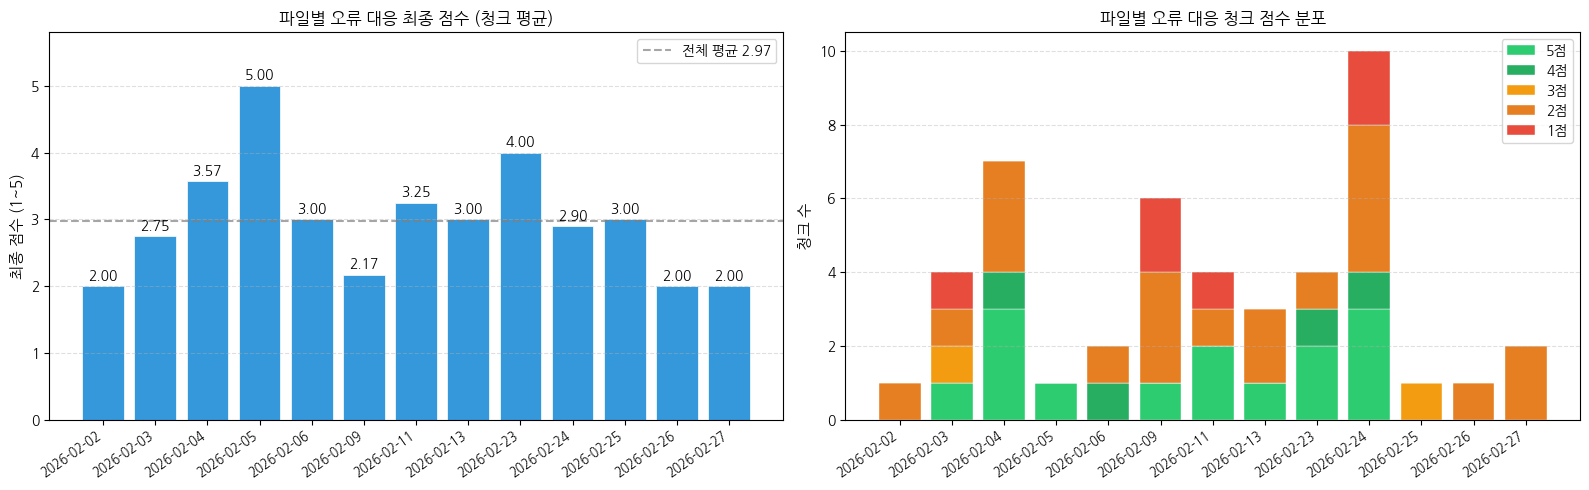

In [65]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

for font in fm.findSystemFonts():
    if any(k in font for k in ["AppleGothic", "NanumGothic", "Malgun", "NotoSansCJK"]):
        plt.rcParams["font.family"] = fm.FontProperties(fname=font).get_name()
        break
plt.rcParams["axes.unicode_minus"] = False

files      = file_scores.index.tolist()
labels     = [f[:10] for f in files]
x          = range(len(files))
score_cols = ["n_score5", "n_score4", "n_score3", "n_score2", "n_score1"]
colors     = ["#2ecc71", "#27ae60", "#f39c12", "#e67e22", "#e74c3c"]
score_lbls = ["5점", "4점", "3점", "2점", "1점"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 왼쪽: 파일별 최종 점수 (평균)
ax1 = axes[0]
bars = ax1.bar(list(x), file_scores["final_score"],
               color="#3498db", edgecolor="white", linewidth=0.5)
for bar, score in zip(bars, file_scores["final_score"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f"{score:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
overall_mean = file_scores["final_score"].mean()
ax1.axhline(y=overall_mean, color="gray", linestyle="--", alpha=0.7,
            label=f"전체 평균 {overall_mean:.2f}")
ax1.set_xticks(list(x))
ax1.set_xticklabels(labels, rotation=35, ha="right", fontsize=9)
ax1.set_ylabel("최종 점수 (1~5)", fontsize=11)
ax1.set_ylim(0, 5.8)
ax1.set_title("파일별 오류 대응 최종 점수 (청크 평균)", fontsize=12, fontweight="bold")
ax1.legend(fontsize=10)
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# 오른쪽: 청크별 점수 분포 stacked bar
ax2 = axes[1]
bottom = [0] * len(files)
for col, color, lbl in zip(score_cols, colors, score_lbls):
    vals = file_scores[col].tolist()
    ax2.bar(list(x), vals, bottom=bottom, color=color, label=lbl,
            edgecolor="white", linewidth=0.3)
    bottom = [b + v for b, v in zip(bottom, vals)]
ax2.set_xticks(list(x))
ax2.set_xticklabels(labels, rotation=35, ha="right", fontsize=9)
ax2.set_ylabel("청크 수", fontsize=11)
ax2.set_title("파일별 오류 대응 청크 점수 분포", fontsize=12, fontweight="bold")
ax2.legend(fontsize=10, loc="upper right")
ax2.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()